# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**: Christine Swanson 

**Team Mates:** Madeline Allen, Sandeep Poudel

**ID**: cms549

> **Due Date**
>
> Friday, 4/11/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Packages

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [1]:
# from ChatGPT, convert provided Julia packages to Python (see references)
import random            # Random number generation and seed-setting
import pandas as pd      # Tabular data structure
import scipy.stats as stats  # Probability distributions
import matplotlib.pyplot as plt  # Plotting library
import numpy as np       # For statistical quantities like mean, median, etc
import seaborn as sns    # Additional statistical plotting tools
from scipy.optimize import minimize  # optimization tools (equivalent to Optim in Julia)
from scipy.stats import poisson, norm # for problem 1 Poisson regression, norm for problem 2

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

In [44]:
# set the seed
np.random.seed(44)

In [45]:
# load the salamander data

# data are separated by a semicolon
salamander_data = pd.read_csv("./data/salamanders.csv", 
                              sep=";", header=0) 

In [46]:
# from HW2
# standardize the predictors (percent ground cover and age 
# of forest plot), as they are much larger than the counts

# create a copy of the data frame
salamander_data_normalized = salamander_data.copy() 

# subtract off the mean and divide by the standard deviation
salamander_data_normalized["PCTCOVER"] = (salamander_data["PCTCOVER"] - \
                                          np.mean(salamander_data["PCTCOVER"]))/np.std(salamander_data["PCTCOVER"])
salamander_data_normalized["FORESTAGE"] = (salamander_data["FORESTAGE"] - \
                                           np.mean(salamander_data["FORESTAGE"]))/np.std(salamander_data["FORESTAGE"])

In [47]:
# from HW2
# fit Poisson regression model just using GROUND COVER as a predictor
# see reference to ChatGPT for converting the class code to Python

# code from BEE-5850 Probability Models lecture 
# Poisson log-likelihood function
def salamander_model(params, pctcover, salamanders_count):
    β0, β1 = params
    λ = np.exp(β0 + β1 * pctcover) 
    loglik = np.sum(poisson.logpmf(salamanders_count, λ)) 
    return loglik

# load data
pctcover = salamander_data_normalized["PCTCOVER"]
salamanders_count = salamander_data_normalized["SALAMAN"]

# Set bounds and initial values
lb = [-100.0, -100.0]
ub = [100.0, 100.0]
init = [0.0, 0.0]
bounds = list(zip(lb, ub))

# optimize (maximize the log-likelihood)
result = minimize(lambda θ: -salamander_model(θ, 
                                              pctcover, 
                                              salamanders_count),
                  init, bounds=bounds)

# get the MLE estimates 
θ_mle = result.x 
print(f"θ_mle (PCTCOVER): {θ_mle.round(2)}") 

θ_mle (PCTCOVER): [0.43 1.15]


In [48]:
# use 1,000 NON-PARAMETRIC bootstrap samples to obtain estimates of
# bias and the 90% confidence interval for the intercept and
# coefficient in the Poisson regression

# code adapted from BEE6310 HW1, problem 11 to get 95% CIs on 
# MLE parameter estimates
# each parameter will have its own CI (one CI for intercept, one CI for coefficient)

# number of bootstrap samples
B = 1000

# non-parametric bootstrapping
boot_intercepts = np.empty(B)
boot_slopes = np.empty(B)

# Poisson log-likelihood function (cleaned up from above)
def poisson_loglik(params, x, y):
    β0, β1 = params
    λ = np.exp(β0 + β1 * x)
    return np.sum(poisson.logpmf(y, λ)) # log-likelihood 

# define neg log-likelihood for minimization
# this is b/c scipy.optimize.minimize minimizes functions
def neg_loglik(params, x, y):
    return -poisson_loglik(params, x, y)

# re-define the response and target variables 
x_data = salamander_data_normalized["PCTCOVER"].values
y_data = salamander_data_normalized["SALAMAN"].values

# non-parametric bootstrap 
for b in np.arange(0,B):
  # randomly sample ROW indices with REPLACEMENT 
  # this way, we preserve the relationship between each 
  # observation’s ground cover and salamander count
  sample_indices = np.random.choice(len(salamander_data_normalized),
                                        size=len(salamander_data_normalized),
                               replace=True)
  
  # extract the data (gound cover and salamander counts) 
  # at the bootstrap sample indices
  x_boot = x_data[sample_indices]
  y_boot = y_data[sample_indices]

  # optimize (MLE) on the bootstrap sample
  # references scipy.optimize.minimize documentation
  result = minimize(neg_loglik, x0=[0.0, 0.0], args=(x_boot, y_boot),
                   bounds=[(-100, 100), (-100, 100)])
  
  # estimate slope and intercept for each bootstrap sample
  boot_intercepts[b] = result.x[0]
  boot_slopes[b] = result.x[1]

In [49]:
# original MLE parameter estimates (re-define in case overwritten)
intercept_hat, slope_hat = θ_mle

# calculate bootstrap bias (intercept and coefficient)
# equation from Bootstrap lecture, slide 17
# apply expectation to bootstrap estimates, 
# subtract off the estimate of the statistic from the sample
bias_intercept = np.mean(boot_intercepts) - intercept_hat
bias_slope = np.mean(boot_slopes) - slope_hat

# 90% confidence intervals (5th and 95th percentiles)
# for intercept and coefficient 
# this is the basic bootstrap CI formula 
ci90_intercept =  2*intercept_hat - np.quantile(boot_intercepts, [0.95, 0.05])
ci90_slope = 2*slope_hat - np.quantile(boot_slopes, [0.95, 0.05])

# print the output
# switch the list so the lower and upper bounds are right
# 2*t_hat - quantile 

print(f"MLE estimates: Intercept = {intercept_hat:.2f}, Slope = {slope_hat:.2f}")
print(f"Bootstrap bias: Intercept = {bias_intercept:.2f}, Slope = {bias_slope:.2f}")
print(f"90% CI for Intercept: {ci90_intercept.round(2)}")
print(f"90% CI for Slope: {ci90_slope.round(2)}")

MLE estimates: Intercept = 0.43, Slope = 1.15
Bootstrap bias: Intercept = -0.04, Slope = 0.03
90% CI for Intercept: [0.13 0.87]
90% CI for Slope: [0.68 1.47]


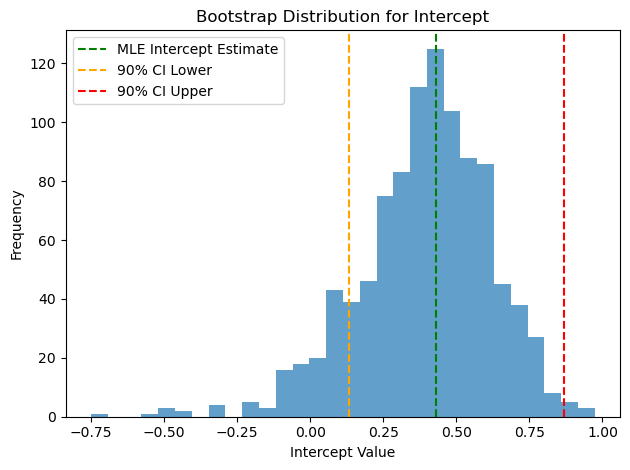

In [50]:
# plot histogram - intercept parameter 
plt.hist(boot_intercepts, bins=30, alpha=0.7)

ci_upper = 2 * intercept_hat - np.percentile(boot_intercepts, 5)
ci_lower = 2 * intercept_hat - np.percentile(boot_intercepts, 95)

plt.axvline(intercept_hat, color = "green", linestyle = "--", label = "MLE Intercept Estimate")
plt.axvline(ci_lower, color='orange', linestyle='--', label='90% CI Lower')
plt.axvline(ci_upper, color='red', linestyle='--', label='90% CI Upper')

plt.title("Bootstrap Distribution for Intercept")
plt.xlabel("Intercept Value")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()

plt.show()

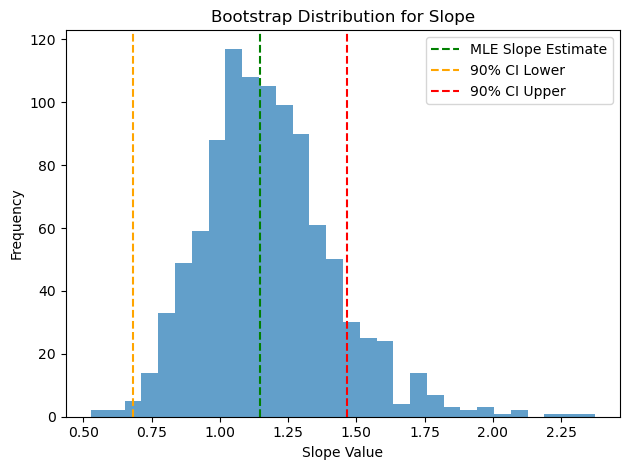

In [51]:
# plot histogram - slope parameter 
plt.hist(boot_slopes, bins=30, alpha=0.7)

ci_upper = 2 * slope_hat - np.percentile(boot_slopes, 5)
ci_lower = 2 * slope_hat - np.percentile(boot_slopes, 95)

plt.axvline(slope_hat, color = "green", linestyle = "--", label = "MLE Slope Estimate")
plt.axvline(ci_lower, color='orange', linestyle='--', label='90% CI Lower')
plt.axvline(ci_upper, color='red', linestyle='--', label='90% CI Upper')

plt.title("Bootstrap Distribution for Slope")
plt.xlabel("Slope Value")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()

plt.show()

**RESPONSE AND EXPLANATION OF PROBLEM SOLUTION: For this problem, I used the same code from HW#2 up through fitting the Poisson regression model using just ground cover to get the MLE estimates. Then, I performed the non-parametric bootstrapping for the intercept and slope parameters by defining the Poisson log-likelihood function, the negative log-likelihood (to be used in the minimization procedure), and then performing the bootstrapping by making sure to sample from the *rows* (with replacement) to ensure I was retaining the structure of the data and keeping the underlying data generating process. The Bootstrap bias for the intercept in -0.04 and the Bootstrap bias for the slope is 0.03. The 90% CI for intercept is [0.13, 0.87], and the 90% CI for the slope is [0.68, 1.47].**

### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with **AR(1)
    residuals**.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?

In [37]:
# load the data

# global mean temp data
temp_data = pd.read_csv("./data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", 
                        sep=",", header=0)

# sea level data
sea_lvl_data = pd.read_csv("./data/CSIRO_Recons_gmsl_yr_2015.csv", 
                           sep=",", header=0)

In [38]:
# normalize the data by subtracting off the mean from 1980-1999
# from HW2
temp_data["Anomaly_deg_C_normalized"] = temp_data["Anomaly (deg C)"] - \
    np.mean(temp_data["Anomaly (deg C)"][130:150]) # 1980-1999 indices
sea_lvl_data["GMSL_mm_normalized"] = sea_lvl_data["GMSL (mm)"] - \
    np.mean(sea_lvl_data["GMSL (mm)"][100:120]) # 1980-1999 indices

In [39]:
# subset the temp data to years we have sea level data (1880-2013)
# from HW2
temp_data = temp_data[(temp_data["Time"] >= 1880) & (temp_data["Time"] <= 2013)]

temp_data = temp_data.reset_index(drop=True) # need to reset the index after filtering the rows 

In [40]:
# from HW2
# function to simulate global mean sea levels under set of model 
# params after discretizing eqns 

# create model for sea level based on temp
def sea_level_model(global_temp, p=(1,1,1,1)): # params = a, b, tau, S0

    # define our unknown param values based on input to function
    a, b, tau, S0 = p

    dt = 1 # 1 year
    
    T = global_temp

    S = np.zeros(len(T))

    # initial sea level parameter, S0
    S[0] = S0

    for i in range(len(T) - 1):
        S[i+1] = S[i] + ((a * T[i] + b - S[i])/tau)*dt
    return S

def sea_level_model_wrap(params):
    return sea_level_model(global_temp=temp_data['Anomaly_deg_C_normalized'], 
                           p=params)

In [41]:
# fit model under assumption of AR(1) residuals by MLE

# note: don't need to include observation uncertainty here (from office hours)

# likelihood for AR(1) process
# adapted from Time Series Lecture class notes
# whitened: remove inter-temporal correlation 
def ar1_loglik_whitened(theta, dat):
    # unpack parameters
    rho, sigma = theta
    T = len(dat)
    ll = 0  # initialize log-likelihood

    for i in range(T):
        if i == 0:
            ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(dat[i], loc=rho * dat[i-1], scale=sigma)

    return ll

# calculate residuals and pass to AR(1) likelihood function 
def ar1_model_loglik(params, sea_level_obs, model_func):
    # unpack parameters: a, b, tau, S0, rho, sigma
    a, b, tau, S0, rho, sigma = params

    # simulated sea level from model
    sea_level_sim = model_func((a, b, tau, S0))

    # compute residuals between observed and simulated sea levels
    # residual defined as differnece between predicted and observed value 
    # this is epsilon_t
    residuals = sea_level_obs - sea_level_sim

    # compute AR(1) log-likelihood using whitened approach (above)
    # of this residual series 
    ll = ar1_loglik_whitened((rho, sigma), residuals)

    return ll

# negative log-likelihood wrapper 
def neg_log_likelihood_ar1(params):
    return -ar1_model_loglik(
        params,
        sea_level_obs=sea_lvl_data["GMSL_mm_normalized"],
        model_func=sea_level_model_wrap
    )

# initial guesses: a, b, tau, S0, rho, sigma
p0 = [1.0, 1.0, 1.0, 1.0, 0.5, 1.0]

# set the bounds really wide, to avoid estimating parameter 
# exactly as upper or lower bound
lower = [-2000, -2000, 0.1, -2000, -0.99, 0]
upper = [2000, 2000, 2000, 2000, 0.99, 10.0]

# note that the choice of solver for the optimization will impact the results
result = minimize(neg_log_likelihood_ar1, p0, 
                  bounds=list(zip(lower, upper)), method="SLSQP") 

θ_ar1 = result.x

c:\Users\cms549\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2029: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


In [54]:
# print the parameter estimates from above 
print("Estimate of 'a': ", θ_ar1[0].round(2), "mm/deg°C")
print("Estimate of 'b': ", θ_ar1[1].round(2), "mm")
print("Estimate of tau: ", θ_ar1[2].round(2), "years")
print("Estimate of S0: ", θ_ar1[3].round(2), "mm")
print("Estimate of rho: ", θ_ar1[4].round(2), "") # autoregressive coefficient (unitless)
print("Estimate of sigma: ", θ_ar1[5].round(2), "mm") # standard deviation of residual
print("Estimate of sensitivity of GMSLR to increase in GMT (a/tau): ", (θ_ar1[0]/θ_ar1[2]).round(2), "mmm/°C/yr") # sensitivity 

Estimate of 'a':  584.17 mm/deg°C
Estimate of 'b':  447.18 mm
Estimate of tau:  192.03 years
Estimate of S0:  -157.99 mm
Estimate of rho:  0.51 
Estimate of sigma:  4.93 mm
Estimate of sensitivity of GMSLR to increase in GMT (a/tau):  3.04 mmm/°C/yr


In [ ]:
# Use your fitted model and the AR(1) residual process to generate
# 1,000 PARAMETRIC bootstrap samples. Refit the model to each. Plot
# histograms of the bootstrap samples for each parameter

# Note to self: Do NOT re-run this code - takes forever

from tqdm import tqdm  # for progress bar (takes a long time to run)
# documentation in references 

# extract model-fitted values and AR(1) params
# fitted values are first 4 params in theta (a, b, tau, S0)
fitted_values = sea_level_model_wrap(θ_ar1[:4])
rho = θ_ar1[4]
sigma = θ_ar1[5]
n = len(fitted_values)

# final run needs 1000 bootstrap samples
n_boot = 1000

# to store results
bootstrap_estimates = np.zeros((n_boot, 6))  # 6 parameters

# bootstrapping loop
for i in tqdm(range(n_boot), desc="Bootstrapping"):

    # simulate AR(1) residuals
    eps = np.zeros(n)
    
    # stationary distribution
    eps[0] = np.random.normal(0, sigma / np.sqrt(1 - rho**2))  

    for t in range(1, n):
        eps[t] = rho * eps[t - 1] + np.random.normal(0, sigma)

    # add on residuals to fitted values 
    simulated_obs = fitted_values + eps

    # define new likelihood with SIMULATED data
    def boot_neg_loglik(params):
        return -ar1_model_loglik(params, sea_level_obs=simulated_obs, 
                                 model_func=sea_level_model_wrap)

    # refit the model
    result = minimize(boot_neg_loglik, p0, bounds=list(zip(lower, upper)))
    bootstrap_estimates[i, :] = result.x

Bootstrapping: 100%|██████████| 1000/1000 [3:01:28<00:00, 10.89s/it]   


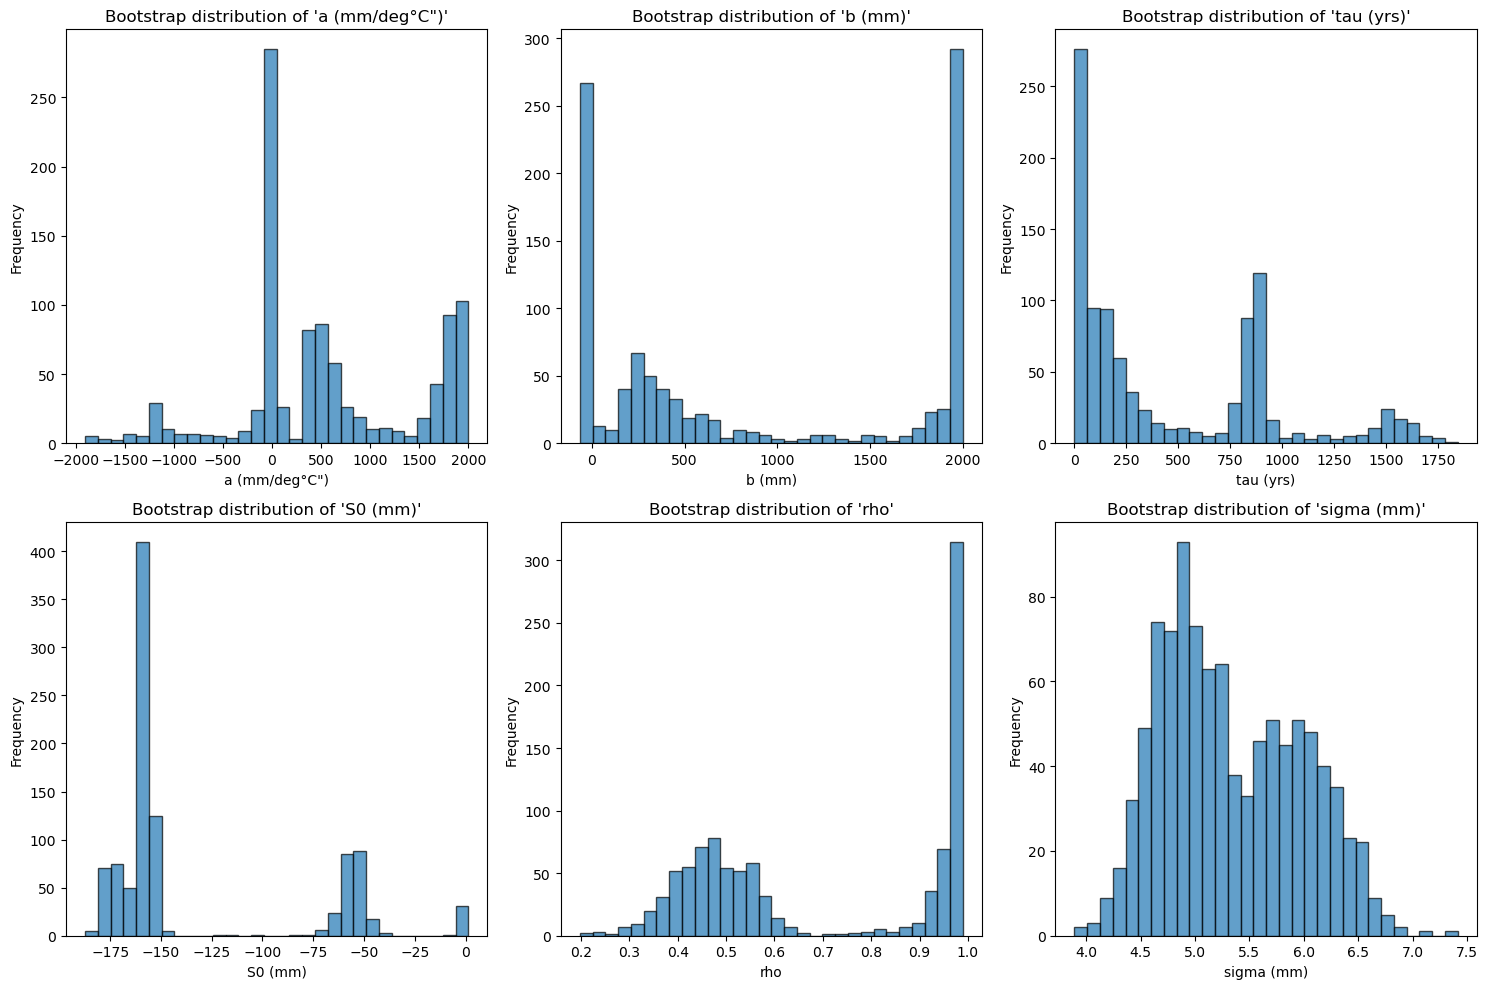

In [59]:
# parameter list 
param_names = ['a (mm/deg°C")', 'b (mm)', 'tau (yrs)', 'S0 (mm)', 'rho', 'sigma (mm)']
n_params = len(param_names)

# plot the histograms of the bootstrap samples
# for each parameter 
plt.figure(figsize=(15, 10))

for i in range(n_params):
    plt.subplot(2, 3, i + 1)  # 2 rows, 3 cols

    plt.hist(bootstrap_estimates[:, i], bins=30, edgecolor='k', alpha=0.7)
    
    plt.title(f"Bootstrap distribution of '{param_names[i]}'")
    plt.xlabel(param_names[i])
    plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [60]:
# what is the 90% confidence interval for the sensitivity of 
# sea level to global mean temperature (a/tau)?
# note, not just the CI for the "a" parameter!

a_samples = bootstrap_estimates[:, 0]  # first column = 'a' parameter

tau_samples = bootstrap_estimates[:, 2]  # third column = 'tau' parameter

a_hat = θ_ar1[0] # MLE estimate of "a"

tau_hat = θ_ar1[2] # MLE estimate of "tau"

# 90% confidence interval (5th to 95th percentile)
# using basic bootstrap CI
# of a/tau (sensitivity of sea level to global mean temperature)

ci90_a_tau = 2*(a_hat/tau_hat) - np.quantile(a_samples/tau_samples, [0.95, 0.05])
print(f"90% CI for sensitivity of sea level to global mean temperature ('a/tau'): {ci90_a_tau[0]:.2f} to {ci90_a_tau[1]:.2f} mm/°C/yr")

90% CI for sensitivity of sea level to global mean temperature ('a/tau'): 0.09 to 7.25 mm/°C/yr


**RESPONSE AND EXPLANATION OF PROBLEM SOLUTION: For this problem, it was similar to HW#2 in that I could keep my code up through the sea level model. However, instead of fitting the model under the assumption of Gaussian iid residuals, I now am fitting the model to the data using AR(1) residuals. That is, I swapped out the gaussian iid function to get the log-likelihood with that of the AR(1) process (which we saw in class, here I am using the whitened approach). Then, I calculate the residuals (difference in observed and simulated sea levels) and pass to the AR(1) likelihood function. I then wrote a function to return the negative log-likelihood, as this is what `scipy.optimize.minimize` requires. I then performed the minimization procedure like I did in HW#2. Please note that the choice of solver in the optimization will impact the results. Regardless, I was able to plot the histogram of the bootstrap samples for each parameter. But, instead of the direct model parameters, we are more interested in the relationship between, here, "a" and tau, as this ratio is well-defined by the temperature and the sea level data (see Vivek's comment in Ed discussion). Thus, more interestingly, I calculated the 90% confidence interval of the sensitivity of sea level to global mean temperature (a/tau) to be 0.09 to 7.25 mm/°C/yr. The sensitivity of sea level to global mean temperature means that if a/tau = 1 mm/°C/yr, then for every 1°C increase in global mean temperature, sea level rises at a rate of 1 mm/yr faster than before. In this case, I can interpret the confidence interval that I am 90% confident that the true sensitivity of sea level rise to global mean temperature lies between 0.09 and 7.25 mm/°C/yr. Therefore, even looking at the lower bound of the confidence interval, increasing global mean temperature still increases the rate of sea level rise (0.09 mm/°C/yr).**

### Problem 3

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

C:\Users\cms549\AppData\Local\Temp\ipykernel_37360\4134491126.py:4: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv(fname, parse_dates=[['Date', 'Time (GMT)']],
C:\Users\cms549\AppData\Local\Temp\ipykernel_37360\4134491126.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = pd.read_csv(fname, parse_dates=[['Date', 'Time (GMT)']],


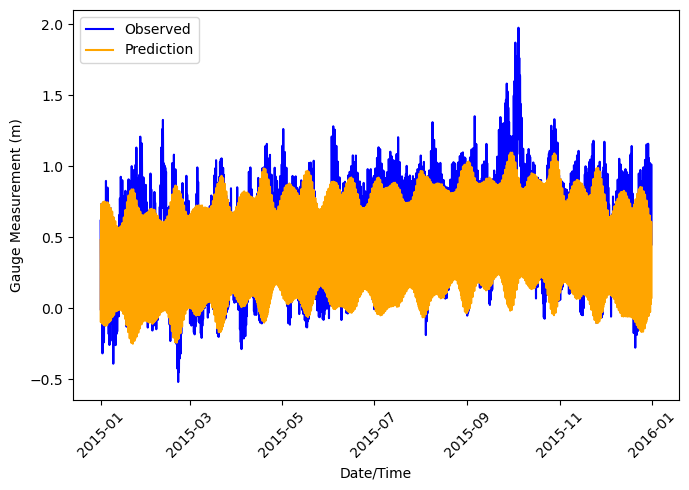

In [19]:
# converted provided Julia to Python using ChatGPT (see references)
def load_data(fname):
    # Load the CSV file with the correct date format
    data = pd.read_csv(fname, parse_dates=[['Date', 'Time (GMT)']], 
                       date_parser=lambda x: pd.to_datetime(x, format='%Y/%m/%d %H:%M'))
    
    # Rename columns for consistency
    data = data.rename(columns={"Time (GMT)": "time", "Predicted (m)": "harmonic", "Verified (m)": "gauge"})
    
    # Create a datetime column
    data['datetime'] = data['Date_Time (GMT)']  # combining 'Date' and 'Time (GMT)' columns
    
    # Compute the weather variable as the difference between the gauge and harmonic
    data['weather'] = data['gauge'] - data['harmonic']
    
    # Extract the month from the datetime column
    data['month'] = data['datetime'].dt.month
    
    return data

# Load the data
dat = load_data("data/norfolk-hourly-surge-2015.csv")

# Plot the data
plt.figure(figsize=(7, 5))

plt.plot(dat['datetime'], dat['gauge'], label="Observed", color='blue')
plt.plot(dat['datetime'], dat['harmonic'], label="Prediction", color='orange')
plt.xlabel("Date/Time")
plt.ylabel("Gauge Measurement (m)")
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

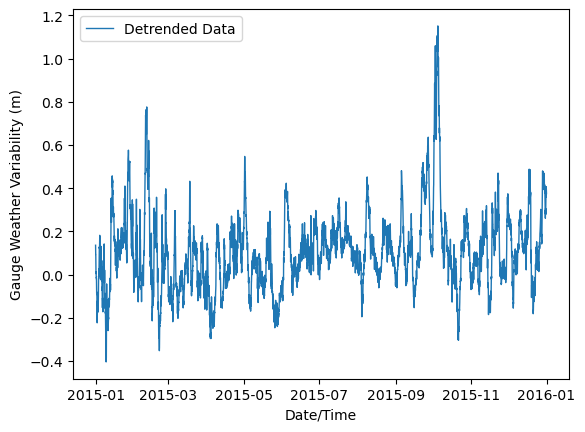

In [20]:
# from ChatGPT (see references)

# Assuming 'dat' is a pandas DataFrame with columns 'datetime' and 'weather'
plt.plot(dat['datetime'], dat['weather'], label='Detrended Data', linewidth=1)

# Adding labels and title
plt.xlabel('Date/Time')
plt.ylabel('Gauge Weather Variability (m)')

# Displaying the legend in the top left corner
plt.legend(loc='upper left')

# Showing the plot
plt.show()

We would like to understand the uncertainty in an estimate of the median
sea level.

**In this problem**:

-   Construct 1,000 bootstrap replicates by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

In [ ]:
# pseudo code for problem 3 (office hours)

# calculate the observed median
# for the bootstrapping, you want to calculate the median for each bootstrap (get 1000 medians)
# then, plot a histogram of those 1000 medians
# to compare the observed median, we want to compute the bias, so we 
# calculate the mean of the 1000 median bootstrap samples 
# so plot the observed median, average of the medians from bootstrapping
# and the 90% CI in the histogram 

In [57]:
# adapted from class code - slide 30 of Bootstrap lecture 
# Task: Construct 1,000 bootstrap replicates by adding a moving block
# bootstrap replicate from the weather-induced variability series
# (with block length 20) to the harmonic prediction. Use these
# replicates to compute a 90% confidence interval. What is the bias of
# the estimator?

# adapted from slide 30
# get the data set up
weather = dat['weather'].values
harmonic = dat['harmonic'].values
n = len(weather)
k = 20  # block size of 20
n_blocks = n - k + 1

# create moving blocks 
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = weather[i:(k + i)]

# Bootstrap 
m = int(np.ceil(n / k))
n_boot = 1000
surge_bootstrap = np.zeros((n, n_boot))

for i in range(n_boot):
    sampled_idxs = np.random.choice(n_blocks, m, replace=True)
    sampled_blocks = np.hstack([blocks[:, idx] for idx in sampled_idxs])
    surge_bootstrap[:, i] = sampled_blocks[:n]  # truncate to original length

# add moving block bootstrap replicate from weather-induced variability series 
# to the harmonic prediction 
synthetic_levels = surge_bootstrap + harmonic[:, np.newaxis]  # shape (n, n_boot)

# compute bootstrap MEDIANS
bootstrap_medians = np.median(synthetic_levels, axis=0)

# compute observed median
observed_series = harmonic + weather
observed_median = np.median(observed_series)

# bias and CI calculations 
bootstrap_mean = np.mean(bootstrap_medians)
bias = bootstrap_mean - observed_median

# basic bootstrap CI
ci_upper = 2 * observed_median - np.percentile(bootstrap_medians, 5)
ci_lower = 2 * observed_median - np.percentile(bootstrap_medians, 95)

# print the results 
print("---Block Length = 20:---")
print(f"Observed median sea level : {observed_median:.3f} m")
print(f"Bootstrap bias: {bias:.3f} m")
print(f"90% Confidence Interval: [{ci_lower:.3f}, {ci_upper:.3f}] m")

---Block Length = 20:---
Observed median sea level : 0.508 m
Bootstrap bias: 0.005 m
90% Confidence Interval: [0.490, 0.516] m


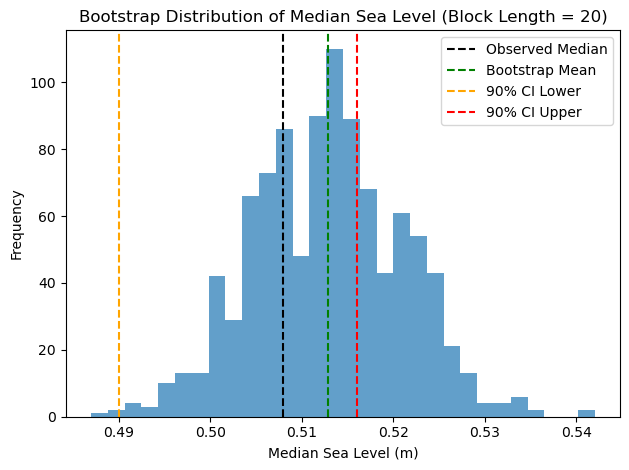

In [58]:
# plot histogram 
plt.hist(bootstrap_medians, bins=30, alpha=0.7)

plt.axvline(observed_median, color='black', linestyle='--', label='Observed Median')
plt.axvline(bootstrap_mean, color = "green", linestyle = "--", label = "Bootstrap Mean")
plt.axvline(ci_lower, color='orange', linestyle='--', label='90% CI Lower')
plt.axvline(ci_upper, color='red', linestyle='--', label='90% CI Upper')
plt.title("Bootstrap Distribution of Median Sea Level (Block Length = 20)")
plt.xlabel("Median Sea Level (m)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

*Note that in the above histogram, the difference between the observed median (black line) and the bootstrap mean (green line) is the bias.*

In [23]:
# repeat with block length of 50

# adapted from class code - slide 30 of Bootstrap lecture 
# Task: Construct 1,000 bootstrap replicates by adding a moving block
# bootstrap replicate from the weather-induced variability series
# (with block length 50) to the harmonic prediction. Use these
# replicates to compute a 90% confidence interval. What is the bias of
# the estimator?

# adapted from slide 30
# get the data set up
weather = dat['weather'].values
harmonic = dat['harmonic'].values
n = len(weather)
k = 50  # block size of 50
n_blocks = n - k + 1

# create moving blocks 
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = weather[i:(k + i)]

# Bootstrap 
m = int(np.ceil(n / k))
n_boot = 1000
surge_bootstrap = np.zeros((n, n_boot))

for i in range(n_boot):
    sampled_idxs = np.random.choice(n_blocks, m, replace=True)
    sampled_blocks = np.hstack([blocks[:, idx] for idx in sampled_idxs])
    surge_bootstrap[:, i] = sampled_blocks[:n]  # truncate to original length

# add moving block bootstrap replicate from weather-induced variability series 
# to the harmonic prediction 
synthetic_levels = surge_bootstrap + harmonic[:, np.newaxis]  # shape (n, n_boot)

# compute bootstrap MEDIANS
bootstrap_medians = np.median(synthetic_levels, axis=0)

# compute observed median
observed_series = harmonic + weather
observed_median = np.median(observed_series)

# bias and CI calculations 
bootstrap_mean = np.mean(bootstrap_medians)
bias = bootstrap_mean - observed_median

# basic bootstrap CI
ci_upper = 2 * observed_median - np.percentile(bootstrap_medians, 5)
ci_lower = 2 * observed_median - np.percentile(bootstrap_medians, 95)

# print the results
print("---Block Length = 50:---") 
print(f"Observed median sea level: {observed_median:.3f} m")
print(f"Bootstrap bias: {bias:.3f} m")
print(f"90% Confidence Interval: [{ci_lower:.3f}, {ci_upper:.3f}] m")

---Block Length = 50:---
Observed median sea level: 0.508 m
Bootstrap bias: 0.004 m
90% Confidence Interval: [0.483, 0.523] m


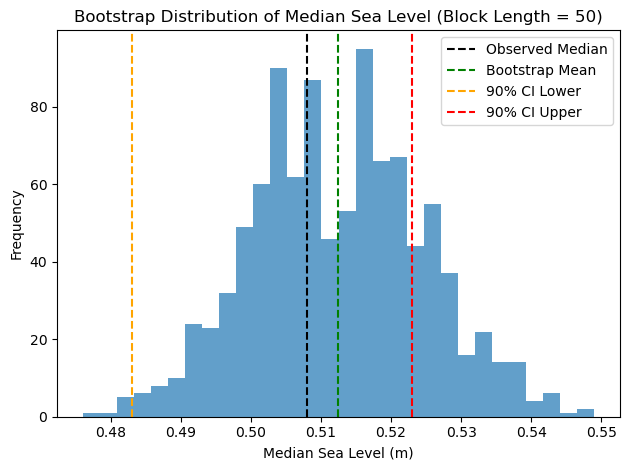

In [24]:
# plot histogram 
plt.hist(bootstrap_medians, bins=30, alpha=0.7)

plt.axvline(observed_median, color='black', linestyle='--', label='Observed Median')
plt.axvline(bootstrap_mean, color = "green", linestyle = "--", label = "Bootstrap Mean")
plt.axvline(ci_lower, color='orange', linestyle='--', label='90% CI Lower')
plt.axvline(ci_upper, color='red', linestyle='--', label='90% CI Upper')
plt.title("Bootstrap Distribution of Median Sea Level (Block Length = 50)")
plt.xlabel("Median Sea Level (m)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

*Question: How does this affect the confidence intervals and estimate of bias? Why do you think using different block lengths produced the results that they did?*

**RESPONSE AND EXPLANATION OF PROBLEM SOLUTION: For this problem to perform the block Bootstrapping, they key steps involved were to calculate the observed median. Then, for the bootstrapping, I calculated the median for each bootstrap to get 1,000 median values. This then allowed me to plot a histogram of the 1,000 median values to compare to the observed median and calculate the bias. The bias is defined here as the difference in the mean of the 1,000 median bootstrap samples to the observed median. With a block length of 20, I calculated a bias of 0.005 m and the 90% confidence interval as [0.490, 0.516] m. Using a block length of 50, I calculated a bias of 0.004 m and the 90% confidence interval as [0.483, 0.523] m. So, we can see that using a larger block length, the bias estimate became smaller (0.005 m-0.004 m =0.001 m), and the 90% confidence interval became wider slightly. I think using different block lengths produced the results that they did (lower bias and slightly wider confidence intervals), as...CONTINUE HERE**

## References and Generative AI Acknowledgement 

OpenAI. (2025). ChatGPT (March 23) version) [Large language model]. https://openai.com/chatgpt [Accessed 23 March 2025]. 

- Problem 0: Setting up packages
    - Prompt I asked ChatGPT: "Convert these Julia packages to Python". That is, I asked it to convert the provided Julia packages to Python.

- Problem 2: Converting the provided Julia class code for AR(1) model (whitened approach) (Time Series Lecture, Slide 21) to Python.
    - Prompt I asked ChatGPT: "Convert this Julia code to Python":
    `function ar1_loglik_whitened(θ, dat)
    ρ, σ = θ
    T = length(dat)
    ll = 0 # initialize log-likelihood counter
    for i = 1:T
        if i == 1
            ll += logpdf(Normal(0, sqrt(σ^2 / (1 - ρ^2))), dat[i])
        else
            ll += logpdf(Normal(ρ * dat[i-1], σ), dat[i])
        end
    end
    return ll
end`

- Problem 3: Converting the provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python":
        `function load_data(fname)
    date_format = "yyyy-mm-dd HH:MM" #this uses the DataFramesMeta package -- it's pretty cool
    return @chain fname begin
        CSV.File(; dateformat=date_format)
        DataFrame
        rename(
            "Time (GMT)" => "time", "Predicted (m)" => "harmonic", "Verified (m)" => "gauge"
        )
        @transform :datetime = (Date.(:Date, "yyyy/mm/dd") + Time.(:time))
        select(:datetime, :gauge, :harmonic)
        @transform :weather = :gauge - :harmonic
        @transform :month = (month.(:datetime))
    end
end
dat = load_data("data/norfolk-hourly-surge-2015.csv")
plot(dat.datetime, dat.gauge; ylabel="Gauge Measurement (m)", label="Observed", legend=:topleft, xlabel="Date/Time", color=:blue)
plot!(dat.datetime, dat.harmonic, label="Prediction", color=:orange)` 

    - Prompt I asked ChatGPT: "Convert this code to Python:" `plot(dat.datetime, dat.weather; ylabel="Gauge Weather Variability (m)", label="Detrended Data", linewidth=1, legend=:topleft, xlabel="Date/Time")`

    - I also ran the provided Julia code for this problem and compared it to the plots in Python to make sure everything was converted/translated correctly. 

    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `k = 20
n_blocks = length(surge_resids) - k + 1
blocks = zeros(Float64, (k, n_blocks))
for i = 1:n_blocks
    blocks[:, i] = surge_resids[i:(k+i-1)]
end
blocks[:, 1:5]`

Python | How to make a terminal progress bar using tqdm. https://www.geeksforgeeks.org/python-how-to-make-a-terminal-progress-bar-using-tqdm/. [Accessed 10 April 2025].

scipy.optimize.minimize documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html. [Accessed 08 April 2025].